# Perceptron Demonstration

## Importing Libraries

In [1]:
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import imageio
import plotly.graph_objects as go
from IPython.display import Image, display

## Setup Output Directory
Cross-platform path that works on both Mac and Windows.

In [2]:
OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)
print(f"Output directory: {OUTPUT_DIR.resolve()}")

Output directory: C:\Users\Sourav Karmakar\Desktop\Work\LogicMojo\logicmojo-data-science-ai-nov-2025\Lecture_materials\Class-41-Intro_to_ANN_and_PyTorch\output


## Perceptron Class

In [3]:
class Perceptron:
    """Common base class for Perceptrons of all types."""

    def __init__(self, input_dim, activation_func='signum'):
        self.input_dim = input_dim
        self.activation_func = activation_func

    def rand_weight_init(self):
        """Random initialization of weights."""
        return np.random.normal(0.03, 0.01, (self.input_dim + 1))

    def output(self, X, w):
        """Compute output after affine transformation and activation function."""
        affine_out = w.T.dot(X)
        if self.activation_func == 'signum':
            return 1 if affine_out >= 0 else -1
        elif self.activation_func in ('sigmoid', 'logistic'):
            return 1 / (1 + np.exp(-affine_out))
        elif self.activation_func == 'tanh':
            return (1 - np.exp(-2 * affine_out)) / (1 + np.exp(-2 * affine_out))
        else:
            print("Error: Wrong activation function input")
            print("Should be either signum, logistic/sigmoid, or tanh")
            return 0

    def train(self, dataset, l_rate=0.1, epsilon=1e-4, max_iteration=20):
        """Learning algorithm for perceptron."""
        if self.input_dim != dataset.shape[1] - 1:
            print("Error: Dimension mismatch between perceptron and dataset")
            return None, None

        no_of_training_examples = dataset.shape[0]
        flag = True
        epoch = 0
        weight_vec_new = self.rand_weight_init()
        weight_mat = weight_vec_new.copy()

        while flag and epoch < max_iteration:
            np.random.shuffle(dataset)
            d = dataset[:, -1]  # Desired output
            X = dataset[:, :-1]
            X = np.column_stack((np.ones(X.shape[0]), X))
            weight_vec_old = weight_vec_new.copy()

            for i in range(no_of_training_examples):
                x = X[i, :]
                y = self.output(x, weight_vec_new)
                weight_vec_new = weight_vec_new + l_rate * (d[i] - y) * x

            epoch += 1
            weight_mat = np.vstack((weight_mat, weight_vec_new))
            w_diff = weight_vec_old - weight_vec_new

            if np.all(np.abs(w_diff) <= epsilon):
                flag = False

        return weight_mat, epoch

    def classify(self, final_w, inp_vec):
        """Classify an input vector using trained weights."""
        x = np.concatenate(([1], np.asarray(inp_vec)))
        y = final_w.T.dot(x)
        if y >= 0:
            print("Class-1")
        else:
            print("Class-2")

---
## Linearly separable data Classification Using Perceptron

### Create Linearly Separable Dataset

In [4]:
class1_2d = np.random.normal(5, 0.8, (200, 2))
x1_2d = class1_2d[:, 0]
y1_2d = class1_2d[:, 1]

class2_2d = np.random.normal(0, 1, (200, 2))
x2_2d = class2_2d[:, 0]
y2_2d = class2_2d[:, 1]

### Plot the Dataset

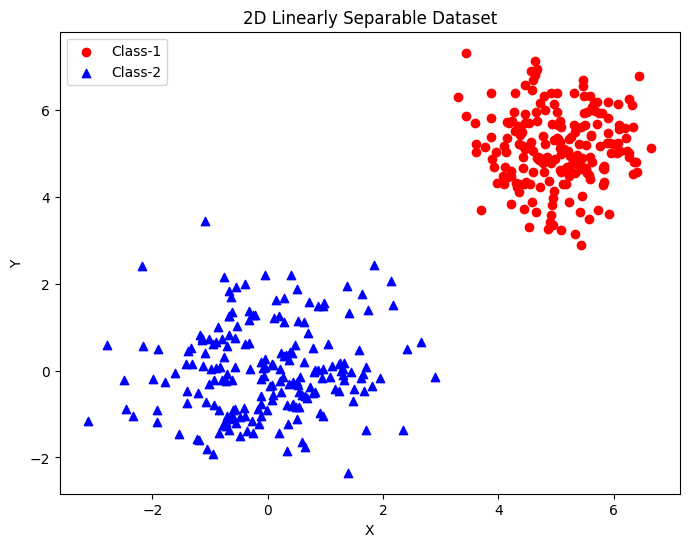

In [5]:
plt.figure(figsize=(8, 6))
plt.scatter(x1_2d, y1_2d, c='r', marker='o', label='Class-1')
plt.scatter(x2_2d, y2_2d, c='b', marker='^', label='Class-2')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.title('2D Linearly Separable Dataset')
plt.show()

### Train the 2D Perceptron

In [6]:
# Merge classes with labels
class1_labeled = np.column_stack((class1_2d, np.ones(class1_2d.shape[0])))
class2_labeled = np.column_stack((class2_2d, -np.ones(class2_2d.shape[0])))
dataset_labeled_2d = np.vstack((class1_labeled, class2_labeled))

# Create and train perceptron
p = Perceptron(2)
weight_matrix_2d, iterations_2d = p.train(dataset_labeled_2d)

final_weights_2d = weight_matrix_2d[iterations_2d, :]
print(f"Training converged in {iterations_2d} epoch(s)")
print(f"Final weights: {final_weights_2d}")

Training converged in 2 epoch(s)
Final weights: [-1.36438095  0.4421587   0.19951706]


### Test Classification

In [7]:
print("Classifying [7, 3]:", end=" ")
p.classify(final_weights_2d, [7, 3])

print("Classifying [-3.5, 2]:", end=" ")
p.classify(final_weights_2d, [-3.5, 2])

Classifying [7, 3]: Class-1
Classifying [-3.5, 2]: Class-2


### Visualize Decision Boundary Across Epochs

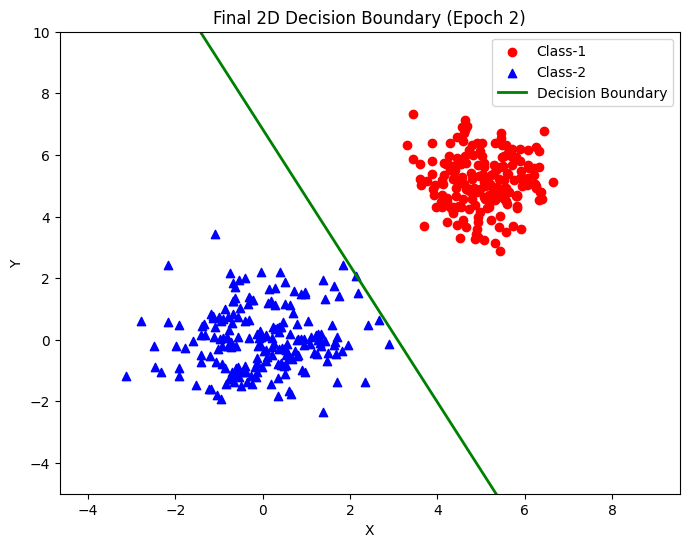

In [8]:
x_range = np.arange(-4, 9, 0.1)
filenames_2d = []

for i in range(iterations_2d + 1):
    y_line = -(weight_matrix_2d[i, 0] + weight_matrix_2d[i, 1] * x_range) / weight_matrix_2d[i, 2]
    plt.figure(figsize=(8, 6))
    plt.scatter(x1_2d, y1_2d, c='r', marker='o', label='Class-1')
    plt.scatter(x2_2d, y2_2d, c='b', marker='^', label='Class-2')
    plt.plot(x_range, y_line, 'g-', linewidth=2)
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.legend()
    plt.title(f'2D Decision Boundary - Epoch {i}')
    plt.ylim(-5, 10)
    filename = OUTPUT_DIR / f'2D_example_{i + 1}.png'
    filenames_2d.append(filename)
    plt.savefig(filename)
    plt.close()

# Show the final decision boundary
y_final = -(weight_matrix_2d[iterations_2d, 0] + weight_matrix_2d[iterations_2d, 1] * x_range) / weight_matrix_2d[iterations_2d, 2]
plt.figure(figsize=(8, 6))
plt.scatter(x1_2d, y1_2d, c='r', marker='o', label='Class-1')
plt.scatter(x2_2d, y2_2d, c='b', marker='^', label='Class-2')
plt.plot(x_range, y_final, 'g-', linewidth=2, label='Decision Boundary')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.title(f'Final 2D Decision Boundary (Epoch {iterations_2d})')
plt.ylim(-5, 10)
plt.show()

### Create GIF

2D GIF saved to: C:\Users\Sourav Karmakar\Desktop\Work\LogicMojo\logicmojo-data-science-ai-nov-2025\Lecture_materials\Class-41-Intro_to_ANN_and_PyTorch\output\2D_example.gif


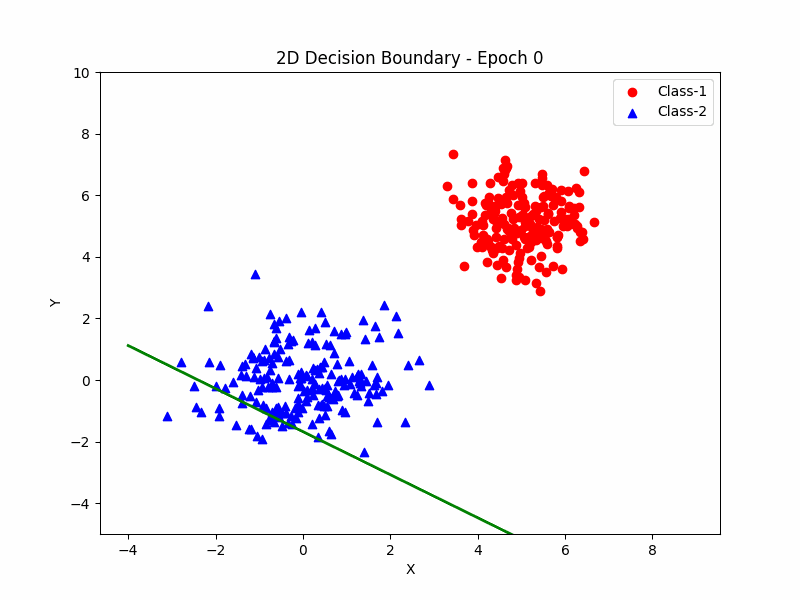

In [9]:
images_2d = [imageio.v2.imread(f) for f in filenames_2d]
gif_path_2d = OUTPUT_DIR / '2D_example.gif'
imageio.mimsave(gif_path_2d, images_2d, duration=500, loop=0)
print(f"2D GIF saved to: {gif_path_2d.resolve()}")
display(Image(filename=str(gif_path_2d)))

---
## Non-Linearly Separable Data Classification Using Perceptron

### Create XOR Dataset

In [10]:
# XOR pattern: Class +1 at (0,0) and (5,5), Class -1 at (5,0) and (0,5)
blob_size = 100
sigma = 0.6

xor_c1_a = np.random.normal(0, sigma, (blob_size, 2))
xor_c1_b = np.random.normal(5, sigma, (blob_size, 2))
xor_class1 = np.vstack((xor_c1_a, xor_c1_b))

xor_c2_a = np.column_stack((np.random.normal(5, sigma, blob_size), np.random.normal(0, sigma, blob_size)))
xor_c2_b = np.column_stack((np.random.normal(0, sigma, blob_size), np.random.normal(5, sigma, blob_size)))
xor_class2 = np.vstack((xor_c2_a, xor_c2_b))

x1_xor = xor_class1[:, 0]
y1_xor = xor_class1[:, 1]
x2_xor = xor_class2[:, 0]
y2_xor = xor_class2[:, 1]

### Plot the XOR Dataset

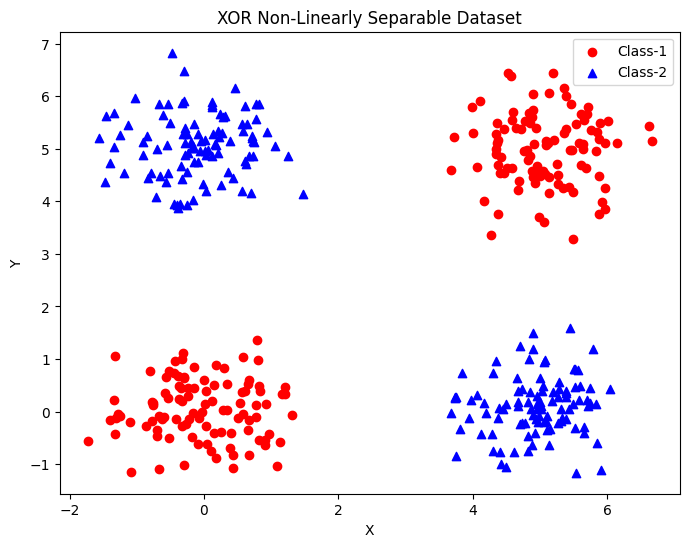

In [11]:
plt.figure(figsize=(8, 6))
plt.scatter(x1_xor, y1_xor, c='r', marker='o', label='Class-1')
plt.scatter(x2_xor, y2_xor, c='b', marker='^', label='Class-2')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.title('XOR Non-Linearly Separable Dataset')
plt.show()

### Train Perceptron on XOR Data

In [12]:
# Merge classes with labels
xor_class1_labeled = np.column_stack((xor_class1, np.ones(xor_class1.shape[0])))
xor_class2_labeled = np.column_stack((xor_class2, -np.ones(xor_class2.shape[0])))
dataset_labeled_xor = np.vstack((xor_class1_labeled, xor_class2_labeled))

# Create and train perceptron
p_xor = Perceptron(2)
weight_matrix_xor, iterations_xor = p_xor.train(dataset_labeled_xor)

final_weights_xor = weight_matrix_xor[iterations_xor, :]
if iterations_xor == 20:
    print(f"Training did NOT converge — stopped at max_iteration={iterations_xor}")
else:
    print(f"Training converged in {iterations_xor} epoch(s)")
print(f"Final weights: {final_weights_xor}")

Training did NOT converge — stopped at max_iteration=20
Final weights: [ 0.41498131 -0.0326671  -0.5554458 ]


### Visualize Decision Boundary Across Epochs

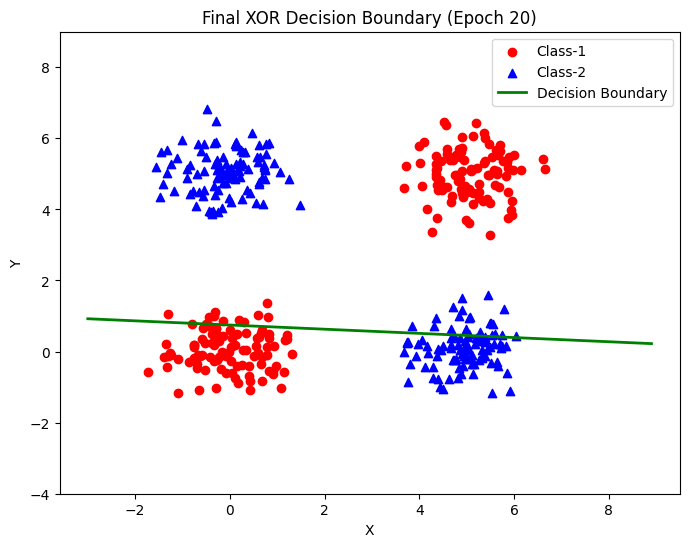

In [13]:
x_range_xor = np.arange(-3, 9, 0.1)
filenames_xor = []

for i in range(iterations_xor + 1):
    if weight_matrix_xor[i, 2] == 0:
        continue
    y_line = -(weight_matrix_xor[i, 0] + weight_matrix_xor[i, 1] * x_range_xor) / weight_matrix_xor[i, 2]
    plt.figure(figsize=(8, 6))
    plt.scatter(x1_xor, y1_xor, c='r', marker='o', label='Class-1')
    plt.scatter(x2_xor, y2_xor, c='b', marker='^', label='Class-2')
    plt.plot(x_range_xor, y_line, 'g-', linewidth=2)
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.legend()
    plt.title(f'XOR Decision Boundary - Epoch {i}')
    plt.ylim(-4, 9)
    filename = OUTPUT_DIR / f'XOR_example_{i + 1}.png'
    filenames_xor.append(filename)
    plt.savefig(filename)
    plt.close()

# Show the final decision boundary
y_final_xor = -(weight_matrix_xor[iterations_xor, 0] + weight_matrix_xor[iterations_xor, 1] * x_range_xor) / weight_matrix_xor[iterations_xor, 2]
plt.figure(figsize=(8, 6))
plt.scatter(x1_xor, y1_xor, c='r', marker='o', label='Class-1')
plt.scatter(x2_xor, y2_xor, c='b', marker='^', label='Class-2')
plt.plot(x_range_xor, y_final_xor, 'g-', linewidth=2, label='Decision Boundary')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.title(f'Final XOR Decision Boundary (Epoch {iterations_xor})')
plt.ylim(-4, 9)
plt.show()

### Create GIF

XOR GIF saved to: C:\Users\Sourav Karmakar\Desktop\Work\LogicMojo\logicmojo-data-science-ai-nov-2025\Lecture_materials\Class-41-Intro_to_ANN_and_PyTorch\output\XOR_example.gif


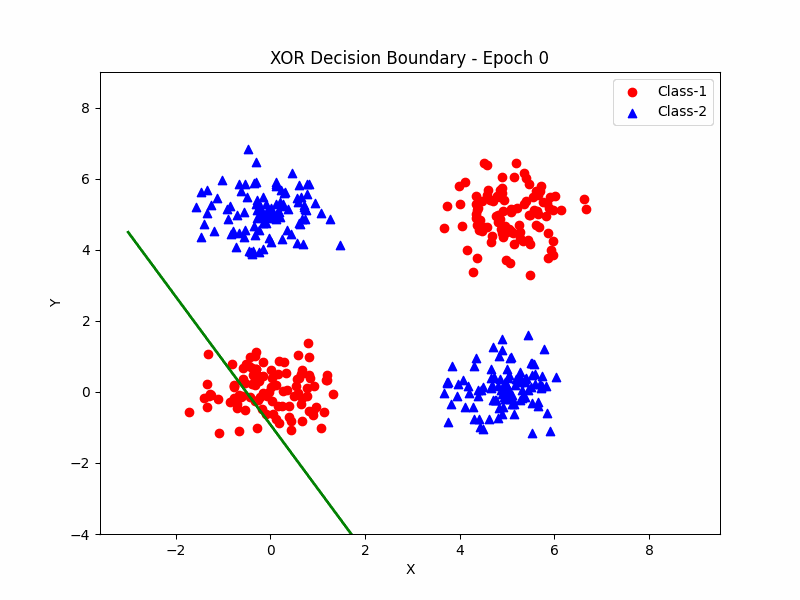

In [14]:
images_xor = [imageio.v2.imread(f) for f in filenames_xor]
gif_path_xor = OUTPUT_DIR / 'XOR_example.gif'
imageio.mimsave(gif_path_xor, images_xor, duration=500, loop=0)
print(f"XOR GIF saved to: {gif_path_xor.resolve()}")
display(Image(filename=str(gif_path_xor)))